# Notebook 05: Model Comparison and Threshold Strategy

This notebook compares stronger models and converts predicted readmission probabilities into an operational threshold strategy.

The goals are:

- load the model-ready dataset
- recreate the patient-aware train/test split
- train stronger models
- compare model performance
- generate predicted readmission risk scores
- evaluate top-risk groups
- simulate outreach capacity at top 5%, 10%, and 20%
- select a provisional model and outreach threshold

This notebook focuses on model comparison and capacity-constrained prioritization.

It does not perform fairness/subgroup review yet.

## 1. Imports

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import GroupShuffleSplit
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.model_selection import StratifiedGroupKFold

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report,
    RocCurveDisplay,
    PrecisionRecallDisplay
)

pd.set_option("display.max_columns", 140)
pd.set_option("display.max_rows", 140)

## 2. Project Paths

In [2]:
def find_project_root(start_path=None):
    """
    Finds the project root by walking upward until the cleaned dataset path is found.
    This avoids relying on the current working directory being exactly the project root
    or the notebooks folder.
    """
    start_path = Path.cwd() if start_path is None else Path(start_path)

    for path in [start_path, *start_path.parents]:
        expected_file = path / "data" / "processed" / "diabetes_readmission_cleaned.csv"
        if expected_file.exists():
            return path

    raise FileNotFoundError(
        "Could not locate project root. Expected to find "
        "'data/processed/diabetes_readmission_cleaned.csv' in this folder or a parent folder."
    )


PROJECT_ROOT = find_project_root()

DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"
OUTPUTS = PROJECT_ROOT / "outputs"
FIGURES = OUTPUTS / "figures"
MODEL_RESULTS = OUTPUTS / "model_results"
OUTREACH_LISTS = OUTPUTS / "outreach_lists"

for path in [DATA_PROCESSED, OUTPUTS, FIGURES, MODEL_RESULTS, OUTREACH_LISTS]:
    path.mkdir(parents=True, exist_ok=True)

print("Project root detected successfully.")
print("Project folder:", PROJECT_ROOT.name)



Project root detected successfully.
Project folder: 03_risk_stratification_intervention_prioritization


## 3. Load Model-Ready Data and Feature List

In [3]:
model_ready_path = DATA_PROCESSED / "diabetes_readmission_model_ready.csv"
feature_list_path = MODEL_RESULTS / "feature_list.csv"

assert model_ready_path.exists(), f"Missing model-ready dataset: {model_ready_path}"
assert feature_list_path.exists(), f"Missing feature list: {feature_list_path}"

df_model = pd.read_csv(model_ready_path)
feature_metadata = pd.read_csv(feature_list_path)

print("Model-ready dataset shape:", df_model.shape)
print("Feature metadata shape:", feature_metadata.shape)

display(df_model.head())
display(feature_metadata.head())

Model-ready dataset shape: (101766, 44)
Feature metadata shape: (38, 3)


,encounter_id,patient_nbr,readmitted_30d,race,gender,age,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses,age_midpoint,age_order,total_prior_visits,medication_change_count,A1Cresult_tested_flag,max_glu_serum_tested_flag,prior_outpatient_flag,prior_emergency_flag,prior_inpatient_flag,high_prior_utilization_flag,long_stay_flag,any_medication_change_flag,insulin_flag,diabetes_med_flag,diabetes_med_changed_flag,time_in_hospital_group,total_prior_visits_group,diagnosis_count_group,medication_count_group,admission_type_id_cat,discharge_disposition_id_cat,admission_source_id_cat,diag_1_category,diag_2_category,diag_3_category,medical_specialty_grouped,race_missing_flag,payer_code_missing_flag,medical_specialty_missing_flag,weight_missing_flag
0,2278392,8222157,0,Caucasian,Female,[0-10),1,41,0,1,0,0,0,1,5,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1-2 days,0,1-3,1-10,6,25,1,Diabetes,Missing,Missing,Rare,0,1,0,1
1,149190,55629189,0,Caucasian,Female,[10-20),3,59,0,18,0,0,0,9,15,2,0,1,0,0,0,0,0,0,0,1,1,1,1,3-4 days,0,7-9,11-20,1,1,7,Other,Diabetes,Other,Missing,0,1,1,1
2,64410,86047875,0,AfricanAmerican,Female,[20-30),2,11,5,13,2,0,1,6,25,3,3,0,0,0,1,0,1,0,0,0,0,1,0,1-2 days,2-3,4-6,11-20,1,1,7,Other,Diabetes,Supplementary_V,Missing,0,1,1,1
3,500364,82442376,0,Caucasian,Male,[30-40),2,44,1,16,0,0,0,7,35,4,0,1,0,0,0,0,0,0,0,1,1,1,1,1-2 days,0,7-9,11-20,1,1,7,Other,Diabetes,Circulatory,Missing,0,1,1,1
4,16680,42519267,0,Caucasian,Male,[40-50),1,51,0,8,0,0,0,5,45,5,0,0,0,0,0,0,0,0,0,0,1,1,1,1-2 days,0,4-6,1-10,1,1,7,Neoplasms,Neoplasms,Diabetes,Missing,0,1,1,1


,feature,feature_type,included_in_primary_model
0,time_in_hospital,numeric,True
1,num_lab_procedures,numeric,True
2,num_procedures,numeric,True
3,num_medications,numeric,True
4,number_outpatient,numeric,True


In [4]:
required_columns = [
    "encounter_id",
    "patient_nbr",
    "readmitted_30d"
]

missing_required = [col for col in required_columns if col not in df_model.columns]

assert len(missing_required) == 0, f"Missing required columns: {missing_required}"
assert set(df_model["readmitted_30d"].dropna().unique()) <= {0, 1}, "Target must be binary."

print("Required columns found.")
print(f"Rows: {len(df_model):,}")
print(f"Unique patients: {df_model['patient_nbr'].nunique():,}")
print(f"Baseline 30-day readmission rate: {df_model['readmitted_30d'].mean():.2%}")

Required columns found.
Rows: 101,766
Unique patients: 71,518
Baseline 30-day readmission rate: 11.16%


### Interpretation

The model-ready dataset and feature list loaded successfully.

This notebook uses the same patient-aware modeling logic from Notebook 04.

`encounter_id` and `patient_nbr` are retained for tracking and splitting, but they are not predictive features.

## 4. Define Features, Target, and Groups

In [5]:
target_col = "readmitted_30d"
group_col = "patient_nbr"

feature_cols = feature_metadata["feature"].tolist()

# Keep only features that exist in the model-ready dataset.
feature_cols = [col for col in feature_cols if col in df_model.columns]

forbidden_features = [
    "encounter_id",
    "patient_nbr",
    "readmitted",
    "readmitted_30d"
]

for col in forbidden_features:
    assert col not in feature_cols, f"Forbidden feature found in feature list: {col}"

X = df_model[feature_cols].copy()
y = df_model[target_col].copy()
groups = df_model[group_col].copy()

print("Total features:", len(feature_cols))
print("Target:", target_col)
print("Group column:", group_col)

Total features: 38
Target: readmitted_30d
Group column: patient_nbr


In [6]:
numeric_features = feature_metadata.loc[
    feature_metadata["feature_type"].isin(["numeric", "binary", "missing_indicator"]),
    "feature"
].tolist()

categorical_features = feature_metadata.loc[
    feature_metadata["feature_type"].eq("categorical"),
    "feature"
].tolist()

numeric_features = [col for col in numeric_features if col in X.columns]
categorical_features = [col for col in categorical_features if col in X.columns]

feature_type_summary = pd.DataFrame({
    "feature_type": [
        "numeric_binary_missing_indicator",
        "categorical",
        "total"
    ],
    "feature_count": [
        len(numeric_features),
        len(categorical_features),
        len(numeric_features) + len(categorical_features)
    ]
})

display(feature_type_summary)

,feature_type,feature_count
0,numeric_binary_missing_indicator,27
1,categorical,11
2,total,38


### Interpretation

The feature set comes from Notebook 03.

Numeric, binary, and missingness-indicator features will be treated as numeric.

Categorical features will be imputed and one-hot encoded inside the modeling pipeline.

Identifiers and target-derived fields are excluded.

## 5. Patient-Aware Train/Test Split

In [7]:
# Recreate the patient-aware holdout split used for model comparison.
splitter = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=42
)

train_idx, test_idx = next(splitter.split(X, y, groups=groups))

X_train = X.iloc[train_idx].copy()
X_test = X.iloc[test_idx].copy()

y_train = y.iloc[train_idx].copy()
y_test = y.iloc[test_idx].copy()

groups_train = groups.iloc[train_idx].copy()
groups_test = groups.iloc[test_idx].copy()

tracking_train = df_model.iloc[train_idx][["encounter_id", "patient_nbr"]].copy()
tracking_test = df_model.iloc[test_idx][["encounter_id", "patient_nbr"]].copy()

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (81613, 38)
Test shape: (20153, 38)


In [8]:
train_patients = set(groups_train)
test_patients = set(groups_test)

patient_overlap = train_patients.intersection(test_patients)

assert len(patient_overlap) == 0, "Patient leakage found: some patients appear in both train and test."

split_summary = pd.DataFrame({
    "split": ["train", "test"],
    "encounter_count": [len(X_train), len(X_test)],
    "unique_patient_count": [groups_train.nunique(), groups_test.nunique()],
    "readmission_count": [int(y_train.sum()), int(y_test.sum())],
    "readmission_rate": [y_train.mean(), y_test.mean()]
})

display(split_summary)

print("Patient overlap between train and test:", len(patient_overlap))

,split,encounter_count,unique_patient_count,readmission_count,readmission_rate
0,train,81613,57214,9206,0.112801
1,test,20153,14304,2151,0.106733


Patient overlap between train and test: 0


### Interpretation

The split is patient-aware.

All encounters from the same patient are kept either in train or test.

This prevents patient-level leakage and makes the holdout evaluation more credible than a random row-level split.

## 6. Build Preprocessing Pipeline

In [9]:
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="constant", fill_value="Missing")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", numeric_transformer, numeric_features),
        ("categorical", categorical_transformer, categorical_features)
    ]
)

print("Preprocessor created.")

Preprocessor created.


### Interpretation

Preprocessing is performed inside the model pipeline.

This prevents test-set information from leaking into imputation, scaling, or one-hot encoding.

The pipeline learns preprocessing steps from training data only.

## 7. Define Candidate Models

In [10]:
logistic_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LogisticRegression(
            max_iter=2000,
            class_weight="balanced",
            solver="lbfgs",
            random_state=42
        ))
    ]
)

random_forest_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", RandomForestClassifier(
            n_estimators=150,
            max_depth=10,
            min_samples_leaf=100,
            class_weight="balanced",
            random_state=42,
            n_jobs=-1
        ))
    ]
)

gradient_boosting_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", GradientBoostingClassifier(
            n_estimators=100,
            learning_rate=0.05,
            max_depth=3,
            min_samples_leaf=100,
            random_state=42
        ))
    ]
)

candidate_models = {
    "Logistic Regression": logistic_model,
    "Random Forest": random_forest_model,
    "Gradient Boosting": gradient_boosting_model
}

print("Candidate models:", list(candidate_models.keys()))

Candidate models: ['Logistic Regression', 'Random Forest', 'Gradient Boosting']


In [11]:
# Patient-aware cross-validation on the training set only.
# This estimates metric stability without using the holdout test set for model selection.
cv = StratifiedGroupKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

def top_k_lift(y_true, y_score, top_pct=0.10):
    """
    Calculates lift in the top-risk group.
    Used for outreach-capacity-oriented model comparison.
    """
    eval_df = pd.DataFrame({
        "actual": np.asarray(y_true),
        "score": np.asarray(y_score)
    }).sort_values("score", ascending=False)

    baseline_rate = eval_df["actual"].mean()
    top_n = int(np.ceil(len(eval_df) * top_pct))
    top_rate = eval_df.head(top_n)["actual"].mean()

    return top_rate / baseline_rate if baseline_rate > 0 else np.nan


cv_rows = []

for model_name, model in candidate_models.items():
    print(f"Cross-validating {model_name}...")

    for fold, (cv_train_idx, cv_valid_idx) in enumerate(
        cv.split(X_train, y_train, groups=groups_train),
        start=1
    ):
        X_cv_train = X_train.iloc[cv_train_idx].copy()
        X_cv_valid = X_train.iloc[cv_valid_idx].copy()
        y_cv_train = y_train.iloc[cv_train_idx].copy()
        y_cv_valid = y_train.iloc[cv_valid_idx].copy()

        model.fit(X_cv_train, y_cv_train)
        y_cv_score = model.predict_proba(X_cv_valid)[:, 1]

        cv_rows.append({
            "model": model_name,
            "fold": fold,
            "roc_auc": roc_auc_score(y_cv_valid, y_cv_score),
            "pr_auc": average_precision_score(y_cv_valid, y_cv_score),
            "top_10_lift": top_k_lift(y_cv_valid, y_cv_score, top_pct=0.10)
        })

cv_results = pd.DataFrame(cv_rows)

cv_summary = (
    cv_results
    .groupby("model")
    .agg(
        roc_auc_mean=("roc_auc", "mean"),
        roc_auc_std=("roc_auc", "std"),
        pr_auc_mean=("pr_auc", "mean"),
        pr_auc_std=("pr_auc", "std"),
        top_10_lift_mean=("top_10_lift", "mean"),
        top_10_lift_std=("top_10_lift", "std")
    )
    .reset_index()
    .sort_values("pr_auc_mean", ascending=False)
)

display(cv_summary.round(4))

Cross-validating Logistic Regression...
Cross-validating Random Forest...
Cross-validating Gradient Boosting...


,model,roc_auc_mean,roc_auc_std,pr_auc_mean,pr_auc_std,top_10_lift_mean,top_10_lift_std
0,Gradient Boosting,0.6724,0.0049,0.2227,0.0076,2.3466,0.0599
1,Logistic Regression,0.6724,0.0051,0.2155,0.0072,2.3173,0.0699
2,Random Forest,0.6655,0.0044,0.2093,0.0074,2.2022,0.0556


### Interpretation

Logistic Regression is retained as the baseline benchmark.

Random Forest and Gradient Boosting are added as stronger nonlinear models.

These models are still constrained to reduce overfitting and keep runtime reasonable.

## 8. Evaluation Helper Functions

In [12]:
def evaluate_classifier(model_name, fitted_model, X_test, y_test):
    """
    Evaluates a fitted binary classification model.

    Accuracy is included, but PR AUC, recall, and top-risk capture are more important
    for readmission risk stratification.
    """
    y_pred = fitted_model.predict(X_test)
    y_score = fitted_model.predict_proba(X_test)[:, 1]

    metrics = {
        "model": model_name,
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred, zero_division=0),
        "recall": recall_score(y_test, y_pred, zero_division=0),
        "f1": f1_score(y_test, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_test, y_score),
        "pr_auc": average_precision_score(y_test, y_score)
    }

    confusion = confusion_matrix(y_test, y_pred)

    report = classification_report(
        y_test,
        y_pred,
        output_dict=True,
        zero_division=0
    )

    return metrics, confusion, report, y_score

In [13]:
def evaluate_top_risk_segments(y_true, y_score, model_name, risk_percentages=[0.05, 0.10, 0.20]):
    """
    Evaluates how well a model captures readmissions in the top-risk segments.

    This is the core operational evaluation for limited outreach capacity.
    """
    evaluation_df = pd.DataFrame({
        "actual_readmitted_30d": y_true.values,
        "predicted_risk": y_score
    }).sort_values("predicted_risk", ascending=False).reset_index(drop=True)

    baseline_event_rate = evaluation_df["actual_readmitted_30d"].mean()
    total_readmissions = evaluation_df["actual_readmitted_30d"].sum()
    total_encounters = len(evaluation_df)

    rows = []

    for pct in risk_percentages:
        top_n = int(np.ceil(total_encounters * pct))
        top_group = evaluation_df.head(top_n)

        readmission_count = int(top_group["actual_readmitted_30d"].sum())
        readmission_rate = top_group["actual_readmitted_30d"].mean()

        rows.append({
            "model": model_name,
            "risk_group": f"Top {int(pct * 100)}%",
            "risk_group_pct": pct,
            "encounter_count": top_n,
            "readmission_count": readmission_count,
            "readmission_rate": readmission_rate,
            "baseline_readmission_rate": baseline_event_rate,
            "lift_vs_baseline": readmission_rate / baseline_event_rate if baseline_event_rate > 0 else np.nan,
            "percent_of_total_readmissions_captured": readmission_count / total_readmissions if total_readmissions > 0 else np.nan,
            "recall_at_k": readmission_count / total_readmissions if total_readmissions > 0 else np.nan,
            "precision_at_k": readmission_rate
        })

    return pd.DataFrame(rows)

### Interpretation

Traditional metrics describe general model performance.

Top-risk segment metrics answer the operational question:

> If the care team can only outreach the top 5%, 10%, or 20% highest-risk encounters, how much better is that group than random selection?

For this project, top-risk lift and readmission capture are more business-relevant than accuracy.

## 9. Train and Evaluate Candidate Models

In [14]:
model_metrics = []
confusion_matrices = {}
classification_reports = {}
prediction_scores = {}
fitted_models = {}

for model_name, model in candidate_models.items():
    print(f"Training {model_name}...")

    model.fit(X_train, y_train)

    metrics, confusion, report, y_score = evaluate_classifier(
        model_name=model_name,
        fitted_model=model,
        X_test=X_test,
        y_test=y_test
    )

    model_metrics.append(metrics)
    confusion_matrices[model_name] = confusion
    classification_reports[model_name] = report
    prediction_scores[model_name] = y_score
    fitted_models[model_name] = model

    print(f"{model_name} complete.")

Training Logistic Regression...
Logistic Regression complete.
Training Random Forest...
Random Forest complete.
Training Gradient Boosting...
Gradient Boosting complete.


In [15]:
model_comparison_metrics = pd.DataFrame(model_metrics)

metric_cols = [
    "accuracy",
    "precision",
    "recall",
    "f1",
    "roc_auc",
    "pr_auc"
]

model_comparison_display = model_comparison_metrics.copy()
model_comparison_display[metric_cols] = model_comparison_display[metric_cols].round(4)

display(model_comparison_display.sort_values("pr_auc", ascending=False))

,model,accuracy,precision,recall,f1,roc_auc,pr_auc
2,Gradient Boosting,0.8933,0.5000,0.0005,0.0009,0.6663,0.2066
0,Logistic Regression,0.6677,0.1752,0.5700,0.2680,0.6694,0.2059
1,Random Forest,0.6511,0.1676,0.5718,0.2592,0.6620,0.1978


### Interpretation

This table compares candidate models using standard classification metrics.

Accuracy should not be treated as the main success metric.

The most important metrics for this project are:

- PR AUC
- recall
- top-risk readmission rate
- lift over baseline
- percent of readmissions captured

## 10. ROC Curve

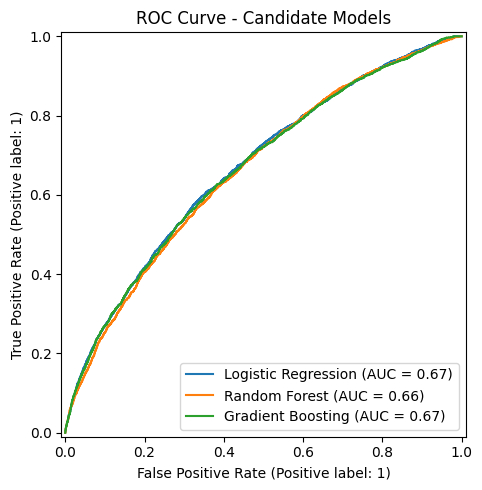

In [16]:
plt.figure(figsize=(7, 5))

for model_name, y_score in prediction_scores.items():
    RocCurveDisplay.from_predictions(
        y_test,
        y_score,
        name=model_name,
        ax=plt.gca()
    )

plt.title("ROC Curve - Candidate Models")
plt.tight_layout()

plt.savefig(FIGURES / "candidate_models_roc_curve.png", dpi=300)
plt.show()

### Interpretation

ROC AUC measures ranking performance across thresholds.

It is useful, but it may look better than the model feels operationally when the positive class is uncommon.

PR AUC and top-risk capture are more important for outreach prioritization.

## 11. Precision-Recall Curve

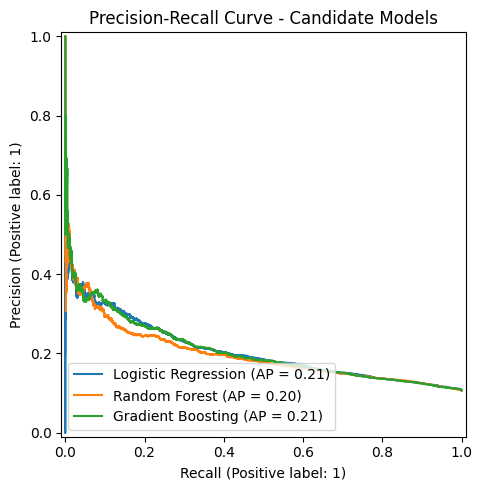

In [17]:
plt.figure(figsize=(7, 5))

for model_name, y_score in prediction_scores.items():
    PrecisionRecallDisplay.from_predictions(
        y_test,
        y_score,
        name=model_name,
        ax=plt.gca()
    )

plt.title("Precision-Recall Curve - Candidate Models")
plt.tight_layout()

plt.savefig(FIGURES / "candidate_models_precision_recall_curve.png", dpi=300)
plt.show()

### Interpretation

The precision-recall curve focuses on positive-class performance.

This is more relevant than accuracy because the project is trying to identify relatively uncommon 30-day readmissions.

## 12. Top-Risk Segment Evaluation

In [18]:
top_risk_results = []

for model_name, y_score in prediction_scores.items():
    model_top_risk = evaluate_top_risk_segments(
        y_true=y_test,
        y_score=y_score,
        model_name=model_name,
        risk_percentages=[0.05, 0.10, 0.20]
    )

    top_risk_results.append(model_top_risk)

top_risk_results = pd.concat(top_risk_results, ignore_index=True)

top_risk_display = top_risk_results.copy()

round_cols = [
    "readmission_rate",
    "baseline_readmission_rate",
    "lift_vs_baseline",
    "percent_of_total_readmissions_captured",
    "recall_at_k",
    "precision_at_k"
]

top_risk_display[round_cols] = top_risk_display[round_cols].round(4)

display(
    top_risk_display
    .sort_values(["risk_group_pct", "lift_vs_baseline"], ascending=[True, False])
)

,model,risk_group,risk_group_pct,encounter_count,readmission_count,readmission_rate,baseline_readmission_rate,lift_vs_baseline,percent_of_total_readmissions_captured,recall_at_k,precision_at_k
0,Logistic Regression,Top 5%,0.05,1008,308,0.3056,0.1067,2.8628,0.1432,0.1432,0.3056
6,Gradient Boosting,Top 5%,0.05,1008,303,0.3006,0.1067,2.8163,0.1409,0.1409,0.3006
3,Random Forest,Top 5%,0.05,1008,275,0.2728,0.1067,2.5561,0.1278,0.1278,0.2728
1,Logistic Regression,Top 10%,0.10,2016,522,0.2589,0.1067,2.4259,0.2427,0.2427,0.2589
7,Gradient Boosting,Top 10%,0.10,2016,520,0.2579,0.1067,2.4166,0.2417,0.2417,0.2579
4,Random Forest,Top 10%,0.10,2016,491,0.2436,0.1067,2.2819,0.2283,0.2283,0.2436
2,Logistic Regression,Top 20%,0.20,4031,827,0.2052,0.1067,1.9222,0.3845,0.3845,0.2052
8,Gradient Boosting,Top 20%,0.20,4031,822,0.2039,0.1067,1.9105,0.3821,0.3821,0.2039
5,Random Forest,Top 20%,0.20,4031,798,0.1980,0.1067,1.8548,0.3710,0.3710,0.1980


In [19]:
top_10_results = top_risk_results[
    top_risk_results["risk_group"] == "Top 10%"
].copy()

top_10_results = top_10_results.sort_values(
    ["lift_vs_baseline", "percent_of_total_readmissions_captured"],
    ascending=False
)

display(top_10_results.round(4))

,model,risk_group,risk_group_pct,encounter_count,readmission_count,readmission_rate,baseline_readmission_rate,lift_vs_baseline,percent_of_total_readmissions_captured,recall_at_k,precision_at_k
1,Logistic Regression,Top 10%,0.1,2016,522,0.2589,0.1067,2.4259,0.2427,0.2427,0.2589
7,Gradient Boosting,Top 10%,0.1,2016,520,0.2579,0.1067,2.4166,0.2417,0.2417,0.2579
4,Random Forest,Top 10%,0.1,2016,491,0.2436,0.1067,2.2819,0.2283,0.2283,0.2436


### Interpretation

Top-risk segment evaluation translates model scores into an outreach capacity question.

Examples:

- Top 5% = very limited outreach capacity
- Top 10% = practical pilot outreach group
- Top 20% = broader outreach program

A useful model should identify top-risk groups with a higher readmission rate than the baseline population.

## 13. Select Provisional Candidate Model

In [20]:
# Select the provisional model using patient-aware cross-validation on the training set.
# This avoids using the holdout test set for both model selection and final reporting.

selected_model_name = (
    cv_summary
    .sort_values(
        ["top_10_lift_mean", "pr_auc_mean", "roc_auc_mean"],
        ascending=False
    )
    .iloc[0]["model"]
)

selected_model_metrics = model_comparison_metrics[
    model_comparison_metrics["model"] == selected_model_name
].copy()

selected_model_cv_summary = cv_summary[
    cv_summary["model"] == selected_model_name
].copy()

selected_model_top_risk = top_risk_results[
    top_risk_results["model"] == selected_model_name
].copy()

print("Selected provisional model:", selected_model_name)

display(selected_model_cv_summary.round(4))
display(selected_model_metrics.round(4))
display(selected_model_top_risk.round(4))

Selected provisional model: Gradient Boosting


,model,roc_auc_mean,roc_auc_std,pr_auc_mean,pr_auc_std,top_10_lift_mean,top_10_lift_std
0,Gradient Boosting,0.6724,0.0049,0.2227,0.0076,2.3466,0.0599


,model,accuracy,precision,recall,f1,roc_auc,pr_auc
2,Gradient Boosting,0.8933,0.5,0.0005,0.0009,0.6663,0.2066


,model,risk_group,risk_group_pct,encounter_count,readmission_count,readmission_rate,baseline_readmission_rate,lift_vs_baseline,percent_of_total_readmissions_captured,recall_at_k,precision_at_k
6,Gradient Boosting,Top 5%,0.05,1008,303,0.3006,0.1067,2.8163,0.1409,0.1409,0.3006
7,Gradient Boosting,Top 10%,0.10,2016,520,0.2579,0.1067,2.4166,0.2417,0.2417,0.2579
8,Gradient Boosting,Top 20%,0.20,4031,822,0.2039,0.1067,1.9105,0.3821,0.3821,0.2039


### Interpretation

The provisional candidate model is selected using patient-aware cross-validation on the training set, with Top 10% lift as the primary business-aligned criterion.

Top 10% lift is used because the project goal is not only general prediction, but outreach prioritization under limited care management capacity.

The holdout test set is then used to estimate how the selected model performs on unseen patients.

This selection is still provisional. The performance differences between Logistic Regression and Gradient Boosting are small, so later notebooks should review calibration, subgroup performance, and operational stability before any deployment-style recommendation.


## 14. Create Test Set Risk Ranking

In [21]:
selected_model_scores = prediction_scores[selected_model_name]

test_risk_ranking = tracking_test.copy()
test_risk_ranking["actual_readmitted_30d"] = y_test.values
test_risk_ranking["predicted_readmission_risk"] = selected_model_scores

test_risk_ranking = test_risk_ranking.sort_values(
    "predicted_readmission_risk",
    ascending=False
).reset_index(drop=True)

test_risk_ranking["risk_rank"] = np.arange(1, len(test_risk_ranking) + 1)
test_risk_ranking["risk_percentile"] = test_risk_ranking["risk_rank"] / len(test_risk_ranking)

display(test_risk_ranking.head(20))

,encounter_id,patient_nbr,actual_readmitted_30d,predicted_readmission_risk,risk_rank,risk_percentile
0,341998334,88227540,1,0.519773,1,0.000050
1,362647880,88227540,0,0.516862,2,0.000099
2,220315764,87452694,1,0.499352,3,0.000149
3,302587472,88227540,1,0.495687,4,0.000198
4,189144708,42941232,1,0.484275,5,0.000248
5,194005518,93205692,0,0.483846,6,0.000298
6,100478628,92118987,0,0.483218,7,0.000347
7,117387726,79729218,1,0.481135,8,0.000397
8,166259388,91751121,0,0.478712,9,0.000447
9,164678202,81169038,1,0.476535,10,0.000496


The predicted scores are used for ranking. They should not yet be interpreted as calibrated probabilities. Probability calibration should be evaluated in a later notebook before using score values as absolute risk estimates.

In [22]:
n_test = len(test_risk_ranking)

top_5_cutoff = int(np.ceil(n_test * 0.05))
top_10_cutoff = int(np.ceil(n_test * 0.10))
top_25_cutoff = int(np.ceil(n_test * 0.25))

def assign_risk_tier_by_rank(risk_rank):
    """
    Assigns risk tiers using rank cutoffs.
    This keeps tier counts consistent with top-risk segment evaluation.
    """
    if risk_rank <= top_5_cutoff:
        return "Very High Risk - Top 5%"
    elif risk_rank <= top_10_cutoff:
        return "High Risk - 5% to 10%"
    elif risk_rank <= top_25_cutoff:
        return "Moderate Risk - 10% to 25%"
    else:
        return "Lower Risk - Bottom 75%"

test_risk_ranking["risk_tier"] = test_risk_ranking["risk_rank"].apply(assign_risk_tier_by_rank)

tier_counts = (
    test_risk_ranking["risk_tier"]
    .value_counts()
    .rename_axis("risk_tier")
    .reset_index(name="encounter_count")
)

display(tier_counts)

,risk_tier,encounter_count
0,Lower Risk - Bottom 75%,15114
1,Moderate Risk - 10% to 25%,3023
2,Very High Risk - Top 5%,1008
3,High Risk - 5% to 10%,1008


Because this notebook uses rank-based thresholds, calibration is not required for the top 5%, 10%, and 20% outreach simulations. However, calibration is required before interpreting predicted scores as absolute probabilities or using fixed probability cutoffs such as `risk >= 0.30`.

### Interpretation

The risk ranking converts predicted probabilities into an operational list.

Each test encounter receives:

- predicted readmission risk
- risk rank
- risk percentile
- risk tier

The risk tier structure prepares the project for the final intervention prioritization notebook.

## 15. Risk Tier Summary

In [23]:
risk_tier_summary = (
    test_risk_ranking
    .groupby("risk_tier", observed=False)
    .agg(
        encounter_count=("encounter_id", "size"),
        readmission_count=("actual_readmitted_30d", "sum"),
        avg_predicted_risk=("predicted_readmission_risk", "mean"),
        observed_readmission_rate=("actual_readmitted_30d", "mean")
    )
    .reset_index()
)

risk_tier_order = [
    "Very High Risk - Top 5%",
    "High Risk - 5% to 10%",
    "Moderate Risk - 10% to 25%",
    "Lower Risk - Bottom 75%"
]

risk_tier_summary["risk_tier"] = pd.Categorical(
    risk_tier_summary["risk_tier"],
    categories=risk_tier_order,
    ordered=True
)

risk_tier_summary = risk_tier_summary.sort_values("risk_tier")

risk_tier_summary["baseline_readmission_rate"] = y_test.mean()
risk_tier_summary["lift_vs_baseline"] = (
    risk_tier_summary["observed_readmission_rate"]
    / risk_tier_summary["baseline_readmission_rate"]
)

display(risk_tier_summary.round(4))

,risk_tier,encounter_count,readmission_count,avg_predicted_risk,observed_readmission_rate,baseline_readmission_rate,lift_vs_baseline
3,Very High Risk - Top 5%,1008,303,0.2868,0.3006,0.1067,2.8163
0,High Risk - 5% to 10%,1008,217,0.1978,0.2153,0.1067,2.0170
2,Moderate Risk - 10% to 25%,3023,443,0.1534,0.1465,0.1067,1.3730
1,Lower Risk - Bottom 75%,15114,1188,0.0860,0.0786,0.1067,0.7364


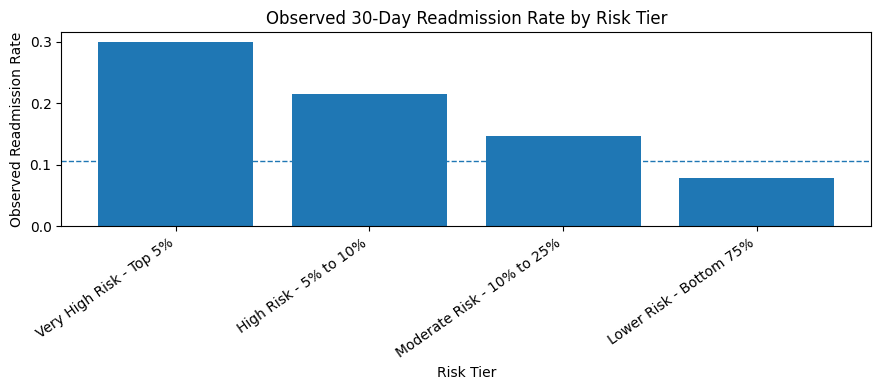

In [24]:
plt.figure(figsize=(9, 4))
plt.bar(
    risk_tier_summary["risk_tier"].astype(str),
    risk_tier_summary["observed_readmission_rate"]
)
plt.axhline(y_test.mean(), linestyle="--", linewidth=1)
plt.title("Observed 30-Day Readmission Rate by Risk Tier")
plt.xlabel("Risk Tier")
plt.ylabel("Observed Readmission Rate")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()

plt.savefig(FIGURES / "observed_readmission_rate_by_risk_tier.png", dpi=300)
plt.show()

### Interpretation

Risk tiers should show a practical gradient:

- higher-risk tiers should have higher observed readmission rates
- lower-risk tiers should have lower observed readmission rates

This helps confirm that the model ranking is directionally useful for prioritization.

## 16. Outreach Capacity Simulation

In [25]:
outreach_capacity_summary = selected_model_top_risk.copy()

outreach_capacity_summary = outreach_capacity_summary[
    [
        "risk_group",
        "encounter_count",
        "readmission_count",
        "readmission_rate",
        "baseline_readmission_rate",
        "lift_vs_baseline",
        "percent_of_total_readmissions_captured"
    ]
].copy()

display(outreach_capacity_summary.round(4))

,risk_group,encounter_count,readmission_count,readmission_rate,baseline_readmission_rate,lift_vs_baseline,percent_of_total_readmissions_captured
6,Top 5%,1008,303,0.3006,0.1067,2.8163,0.1409
7,Top 10%,2016,520,0.2579,0.1067,2.4166,0.2417
8,Top 20%,4031,822,0.2039,0.1067,1.9105,0.3821


### Interpretation

The outreach capacity table shows how model ranking changes the expected readmission rate of the outreach group.

For example:

- Top 5% = smallest group, usually highest risk concentration
- Top 10% = reasonable pilot threshold
- Top 20% = broader outreach but lower risk concentration

The recommended starting point is usually the top 10% because it balances risk concentration and operational feasibility.

## 17. Provisional Threshold Recommendation

### Provisional Recommendation

Based on the threshold strategy, the recommended pilot threshold is:

> Start with the top 10% highest-risk encounters.

Reasoning:

- The top 10% threshold is operationally realistic for a pilot.
- It focuses outreach on encounters with elevated predicted readmission risk.
- It can be expanded to the top 20% if care management capacity allows.
- It can be narrowed to the top 5% if staffing is highly limited.

Important caveat:

This model ranks readmission risk. It does not prove that outreach will reduce readmissions.

To estimate intervention impact, the next step would be a randomized pilot, A/B test, or holdout-based evaluation.

## 18. Export Outputs

In [26]:
model_comparison_output_path = MODEL_RESULTS / "candidate_model_comparison_metrics.csv"
top_risk_output_path = MODEL_RESULTS / "top_risk_segment_evaluation.csv"
selected_model_output_path = MODEL_RESULTS / "selected_candidate_model.csv"
risk_tier_summary_output_path = MODEL_RESULTS / "risk_tier_summary.csv"
outreach_capacity_output_path = MODEL_RESULTS / "outreach_capacity_summary.csv"
test_ranking_output_path = OUTREACH_LISTS / "test_set_risk_ranking.csv"
top_10_outreach_output_path = OUTREACH_LISTS / "top_10_percent_outreach_list.csv"

model_comparison_metrics.to_csv(model_comparison_output_path, index=False)
top_risk_results.to_csv(top_risk_output_path, index=False)
selected_model_metrics.to_csv(selected_model_output_path, index=False)
risk_tier_summary.to_csv(risk_tier_summary_output_path, index=False)
outreach_capacity_summary.to_csv(outreach_capacity_output_path, index=False)
test_risk_ranking.to_csv(test_ranking_output_path, index=False)

top_10_outreach_list = test_risk_ranking[
    test_risk_ranking["risk_rank"] <= top_10_cutoff
].copy()

top_10_outreach_list.to_csv(top_10_outreach_output_path, index=False)

cv_results_output_path = MODEL_RESULTS / "candidate_model_cv_results.csv"
cv_summary_output_path = MODEL_RESULTS / "candidate_model_cv_summary.csv"

cv_results.to_csv(cv_results_output_path, index=False)
cv_summary.to_csv(cv_summary_output_path, index=False)

print("Saved candidate model CV results to:", cv_results_output_path.relative_to(PROJECT_ROOT))
print("Saved candidate model CV summary to:", cv_summary_output_path.relative_to(PROJECT_ROOT))

print("Saved model comparison metrics to:", model_comparison_output_path.relative_to(PROJECT_ROOT))
print("Saved top-risk segment evaluation to:", top_risk_output_path.relative_to(PROJECT_ROOT))
print("Saved selected candidate model to:", selected_model_output_path.relative_to(PROJECT_ROOT))
print("Saved risk tier summary to:", risk_tier_summary_output_path.relative_to(PROJECT_ROOT))
print("Saved outreach capacity summary to:", outreach_capacity_output_path.relative_to(PROJECT_ROOT))
print("Saved test risk ranking to:", test_ranking_output_path.relative_to(PROJECT_ROOT))
print("Saved top 10% outreach list to:", top_10_outreach_output_path.relative_to(PROJECT_ROOT))

Saved candidate model CV results to: outputs\model_results\candidate_model_cv_results.csv
Saved candidate model CV summary to: outputs\model_results\candidate_model_cv_summary.csv
Saved model comparison metrics to: outputs\model_results\candidate_model_comparison_metrics.csv
Saved top-risk segment evaluation to: outputs\model_results\top_risk_segment_evaluation.csv
Saved selected candidate model to: outputs\model_results\selected_candidate_model.csv
Saved risk tier summary to: outputs\model_results\risk_tier_summary.csv
Saved outreach capacity summary to: outputs\model_results\outreach_capacity_summary.csv
Saved test risk ranking to: outputs\outreach_lists\test_set_risk_ranking.csv
Saved top 10% outreach list to: outputs\outreach_lists\top_10_percent_outreach_list.csv


## Notebook 05 Summary

This notebook compared candidate models and translated predicted probabilities into an outreach threshold strategy.

Main work completed:

- Loaded the model-ready dataset and feature list
- Recreated the patient-aware train/test split
- Trained Logistic Regression, Random Forest, and Gradient Boosting models
- Compared models using accuracy, precision, recall, F1, ROC AUC, and PR AUC
- Plotted ROC and precision-recall curves
- Evaluated top 5%, top 10%, and top 20% highest-risk groups
- Selected a provisional candidate model using patient-aware cross-validation and Top 10% lift
- Created risk rankings for the test set
- Assigned risk tiers
- Created a risk tier summary table
- Simulated outreach capacity
- Exported model comparison and outreach-prioritization outputs

Important interpretation rule:

The model ranks readmission risk. It does not prove that outreach will reduce readmissions.

Next step:

Notebook 06 will review subgroup performance and selection patterns across sensitive demographic groups.